79.84882900576076
4974762992232.038
Solution:
$\alpha_a = -0.822865761776914 ==> 0.15036066514651447
$\alpha_n = -1.2767834557078905 ==> 0.05287088064391042
$\Delta_a = 1.1737877674347414 ==> 14.92065083740201
$\Delta_n = 0.25041998854613207 ==> 1.7799999435919247
Relative error: 0.00031787312438395614


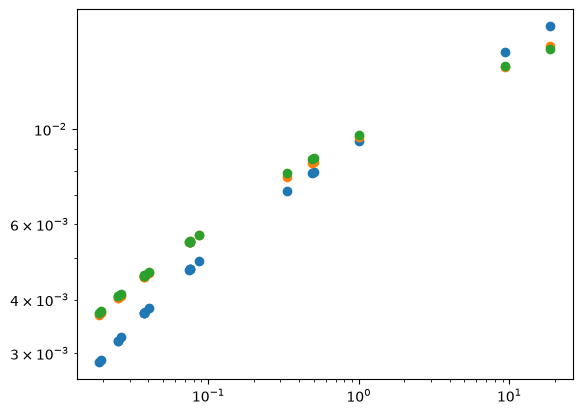

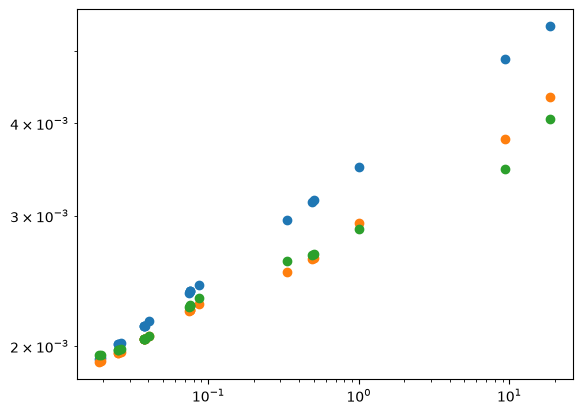

In [11]:
from matplotlib.pyplot import scatter, xscale, show, yscale
from alna.tide_correction_model import tide_angular_frequencies_to_cycle_per_yr
from alna.rheological_formulas import find_tau_m_sup
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import least_squares
from alna.tide_correction_model import (
    SOLID_TIDE_CORRECTION_MODELS_DEFAULT_FILE_NAME,
    POLE_MODELS_PATH,
    load_base_model,
)
from numpy import array, log10
from base_models import load_base_model
from numpy import array
from alna.tide_correction_model import REFERENCE_K2, IERS_LONG_PERIOD_ZONAL_TIDES
from alna.tide_correction_model import POLE_MODELS_PATH

k2_reference = array(
    [
        REFERENCE_K2 + delta_k2_r + 1j * k2_i
        for _, _, delta_k2_r, k2_i in IERS_LONG_PERIOD_ZONAL_TIDES
    ]
)
H_f = abs(
    array(
        [
            0.02793,  # 055.565
            -0.00027,  # 055.575
            -0.00492,  # 056.554 — Sa
            -0.03100,  # 057.555 — Ssa
            0.00077,  # 057.565
            -0.00181,  # 058.554
            -0.00673,  # 063.655 — Msm
            0.00231,  # 065.445
            -0.03518,  # 065.455 — Mm
            0.00229,  # 065.465
            0.00188,  # 065.655
            -0.00583,  # 073.555 — Msf
            -0.00288,  # 075.355
            -0.06663,  # 075.555 — Mf
            -0.02762,  # 075.565
            -0.00258,  # 075.575
            -0.00242,  # 083.655 — Mstm
            -0.01276,  # 085.455 — Mtm
            -0.00529,  # 085.465
            -0.00204,  # 093.555 — Msqm
            -0.00169,  # 095.355 — Mqm
        ]
    )
)
tabs = {
    r"$\alpha_a": array(object=load_base_model(name="lam_values", path=POLE_MODELS_PATH)),
    r"$\alpha_n": array(object=load_base_model(name="lqm_values", path=POLE_MODELS_PATH)),
    r"$\Delta_a": array(object=load_base_model(name="ldm_values", path=POLE_MODELS_PATH)),
    r"$\Delta_n": array(object=load_base_model(name="ltm_values", path=POLE_MODELS_PATH)),
}
k2_models = load_base_model(
    name=SOLID_TIDE_CORRECTION_MODELS_DEFAULT_FILE_NAME, path=POLE_MODELS_PATH
)

interpolated_love_numbers = array(k2_models["k2_real"]) + 1j * array(k2_models["k2_imag"])
grids = tuple(tabs.values())
real_interpolators = [
    RegularGridInterpolator(
        grids,
        interpolated_love_numbers[..., i].real,
        method="linear",
        bounds_error=False,
        fill_value=None,
    )
    for i in range(len(k2_reference))
]
imag_interpolators = [
    RegularGridInterpolator(
        grids,
        interpolated_love_numbers[..., i].imag,
        method="linear",
        bounds_error=False,
        fill_value=None,
    )
    for i in range(len(k2_reference))
]
lower_bounds = array([log10(0.15), -2, log10(3), -1])
upper_bounds = array([log10(0.19), log10(0.21), log10(15), 1])


def predict(p):
    p = array(p, dtype=float)
    return array(
        [
            complex(real_interpolator(p)[0] + 1j * imag_interpolator(p)[0])
            for real_interpolator, imag_interpolator in zip(real_interpolators, imag_interpolators)
        ]
    )


def residuals(p):
    return abs(predict(p) / array(k2_reference, dtype=complex) - 1)


result = least_squares(
    residuals,
    x0=array([log10(0.17), -1, log10(5), 0]),
    bounds=(lower_bounds, upper_bounds),
)
cost = result.cost
x = result.x

print(
    find_tau_m_sup(omega_m_inf=3.09e-4, period_unit=1, alpha=10 ** x[0], delta=10 ** x[2], q_mu=160)
    / 3600
    / 24
    / 365.25
)
print(
    find_tau_m_sup(omega_m_inf=3.09e-4, period_unit=1, alpha=10 ** x[1], delta=10 ** x[3], q_mu=300)
    / 3600
    / 24
    / 365.25
)
print(
    "Solution:\n"
    + "\n".join(
        f"{parameter} = {value} ==> {10**value}" for parameter, value in zip(tabs.keys(), x)
    )
)
print("Relative error:", cost / REFERENCE_K2)
xscale("log")
yscale("log")
scatter(1 / tide_angular_frequencies_to_cycle_per_yr(), k2_reference.real - 0.2979822)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict(x).real - 0.2979822,
)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict([-0.7695, -1.3, 1.17, 0.4]).real - 0.2979822,
)
show()

xscale("log")
yscale("log")
scatter(1 / tide_angular_frequencies_to_cycle_per_yr(), -k2_reference.imag)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    -predict(x).imag,
)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    -predict([-0.7695, -1.3, 1.17, 0.4]).imag,
)

In [16]:
from alna.rheological_formulas import find_tau_m_sup

print(
    find_tau_m_sup(omega_m_inf=3.09e-4, period_unit=1, alpha=10 ** (-1.3), delta=10**0.4, q_mu=300)
    / 3600
    / 24
    / 365.25
)

163931211238199.03


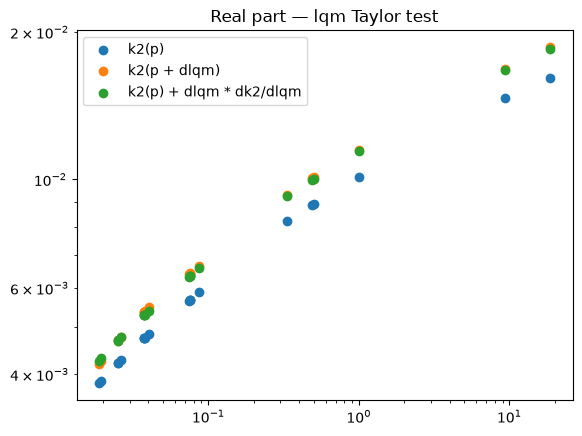

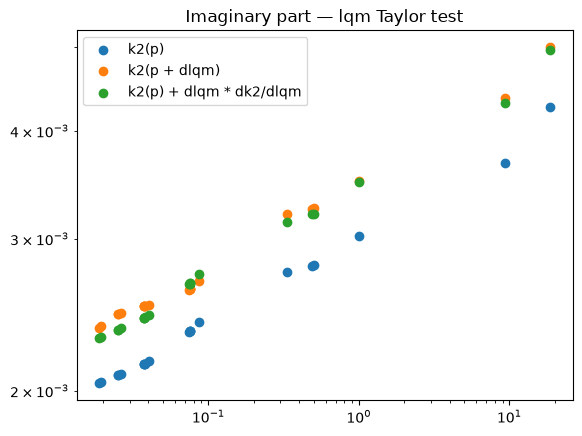

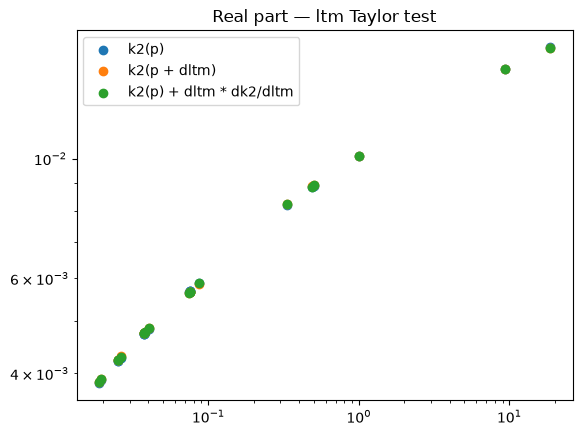

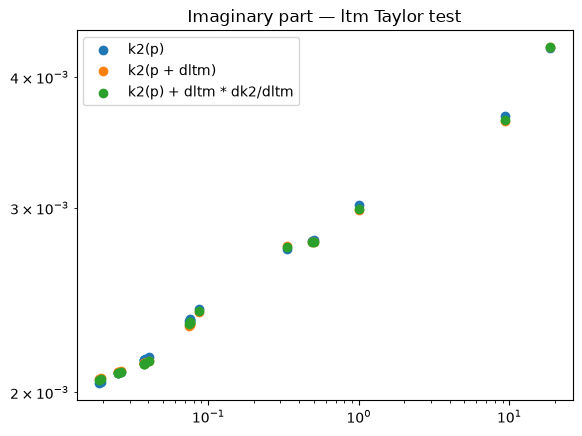


lqm first-order Taylor test
max |exact - Taylor| = 0.0001663449123592072
max relative difference = 0.0005253313981527509

ltm first-order Taylor test
max |exact - Taylor| = 1.2185066045543154e-05
max relative difference = 3.979013923085049e-05


In [17]:
# -------------------------------------------------------------------------
# First-order Taylor tests:
#
#     k2(p + dp) ~= k2(p) + dp * dk2/dp(p)
#
# for:
#     lqm = -1.17, dlqm = 0.1
#     ltm =  0.25, dltm = 0.1
# -------------------------------------------------------------------------

from matplotlib.pyplot import legend, title

p0 = array([-0.7695, -1.27, 1.17, 0.4], dtype=float)

dlqm = 0.1
dltm = 0.1


def build_complex_partial_interpolators(parameter_name):

    real_partial = array(k2_models[f"k2_{parameter_name}_real"])
    imag_partial = array(k2_models[f"k2_{parameter_name}_imag"])

    real_partial_interpolators = [
        RegularGridInterpolator(
            grids,
            real_partial[..., i],
            method="linear",
            bounds_error=False,
            fill_value=None,
        )
        for i in range(len(k2_reference))
    ]

    imag_partial_interpolators = [
        RegularGridInterpolator(
            grids,
            imag_partial[..., i],
            method="linear",
            bounds_error=False,
            fill_value=None,
        )
        for i in range(len(k2_reference))
    ]

    return real_partial_interpolators, imag_partial_interpolators


def predict_partial(p, parameter_name):

    real_partial_interpolators, imag_partial_interpolators = (
        build_complex_partial_interpolators(parameter_name)
    )

    return array(
        [
            complex(
                real_interpolator(p)[0]
                + 1j * imag_interpolator(p)[0]
            )
            for real_interpolator, imag_interpolator in zip(
                real_partial_interpolators,
                imag_partial_interpolators,
            )
        ]
    )


# Base model.
k2_p0 = predict(p0)


# -------------------------------------------------------------------------
# lqm test
# -------------------------------------------------------------------------

p_lqm_plus = p0.copy()
p_lqm_plus[1] += dlqm

k2_lqm_exact = predict(p_lqm_plus)

dk2_dlqm_p0 = predict_partial(
    p=p0,
    parameter_name="lqm",
)

k2_lqm_taylor = (
    k2_p0
    + dlqm * dk2_dlqm_p0
)


# -------------------------------------------------------------------------
# ltm test
# -------------------------------------------------------------------------

p_ltm_plus = p0.copy()
p_ltm_plus[3] += dltm

k2_ltm_exact = predict(p_ltm_plus)

dk2_dltm_p0 = predict_partial(
    p=p0,
    parameter_name="ltm",
)

k2_ltm_taylor = (
    k2_p0
    + dltm * dk2_dltm_p0
)


periods = 1 / tide_angular_frequencies_to_cycle_per_yr()


# -------------------------------------------------------------------------
# REAL PART — lqm
# -------------------------------------------------------------------------

xscale("log")
yscale("log")

scatter(
    periods,
    k2_p0.real - 0.2979822,
    label="k2(p)",
)

scatter(
    periods,
    k2_lqm_exact.real - 0.2979822,
    label="k2(p + dlqm)",
)

scatter(
    periods,
    k2_lqm_taylor.real - 0.2979822,
    label="k2(p) + dlqm * dk2/dlqm",
)

title("Real part — lqm Taylor test")
legend()
show()


# -------------------------------------------------------------------------
# IMAGINARY PART — lqm
# -------------------------------------------------------------------------

xscale("log")
yscale("log")

scatter(
    periods,
    -k2_p0.imag,
    label="k2(p)",
)

scatter(
    periods,
    -k2_lqm_exact.imag,
    label="k2(p + dlqm)",
)

scatter(
    periods,
    -k2_lqm_taylor.imag,
    label="k2(p) + dlqm * dk2/dlqm",
)

title("Imaginary part — lqm Taylor test")
legend()
show()


# -------------------------------------------------------------------------
# REAL PART — ltm
# -------------------------------------------------------------------------

xscale("log")
yscale("log")

scatter(
    periods,
    k2_p0.real - 0.2979822,
    label="k2(p)",
)

scatter(
    periods,
    k2_ltm_exact.real - 0.2979822,
    label="k2(p + dltm)",
)

scatter(
    periods,
    k2_ltm_taylor.real - 0.2979822,
    label="k2(p) + dltm * dk2/dltm",
)

title("Real part — ltm Taylor test")
legend()
show()


# -------------------------------------------------------------------------
# IMAGINARY PART — ltm
# -------------------------------------------------------------------------

xscale("log")
yscale("log")

scatter(
    periods,
    -k2_p0.imag,
    label="k2(p)",
)

scatter(
    periods,
    -k2_ltm_exact.imag,
    label="k2(p + dltm)",
)

scatter(
    periods,
    -k2_ltm_taylor.imag,
    label="k2(p) + dltm * dk2/dltm",
)

title("Imaginary part — ltm Taylor test")
legend()
show()


# -------------------------------------------------------------------------
# Numerical comparison
# -------------------------------------------------------------------------

print("\nlqm first-order Taylor test")
print(
    "max |exact - Taylor| =",
    abs(k2_lqm_exact - k2_lqm_taylor).max(),
)
print(
    "max relative difference =",
    (
        abs(k2_lqm_exact - k2_lqm_taylor)
        / abs(k2_lqm_exact)
    ).max(),
)

print("\nltm first-order Taylor test")
print(
    "max |exact - Taylor| =",
    abs(k2_ltm_exact - k2_ltm_taylor).max(),
)
print(
    "max relative difference =",
    (
        abs(k2_ltm_exact - k2_ltm_taylor)
        / abs(k2_ltm_exact)
    ).max(),
)